# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# Identifying the Principal Component from a Loadings Table

A component's identity is determined by which variable(s) load most heavily (largest
absolute loading) on it — that variable "defines" what the component represents.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030

loadings = pd.DataFrame({
    "Component_1": [0.190, 0.544, 0.782, 0.365, 0.585, 0.394, 0.985, 0.520, 0.142],
    "Component_2": [0.017, 0.020, -0.605, 0.294, 0.085, -0.273, 0.126, 0.402, 0.150],
    "Component_3": [0.207, 0.204, 0.144, 0.585, 0.234, 0.027, -0.111, 0.519, 0.239],
}, index=["Climate", "Housing", "Health", "Crime", "Transportation",
          "Education", "Arts", "Recreation", "Economy"])

loadings


,Component_1,Component_2,Component_3
Climate,0.190,0.017,0.207
Housing,0.544,0.020,0.204
Health,0.782,-0.605,0.144
Crime,0.365,0.294,0.585
Transportation,0.585,0.085,0.234
Education,0.394,-0.273,0.027
Arts,0.985,0.126,-0.111
Recreation,0.520,0.402,0.519
Economy,0.142,0.150,0.239


In [2]:
# The variable with the largest absolute loading defines each component
for col in loadings.columns:
    top_var = loadings[col].abs().idxmax()
    top_val = loadings.loc[top_var, col]
    print(f"{col}: dominant variable = {top_var} (loading = {top_val})")


Component_1: dominant variable = Arts (loading = 0.985)
Component_2: dominant variable = Health (loading = -0.605)
Component_3: dominant variable = Crime (loading = 0.585)


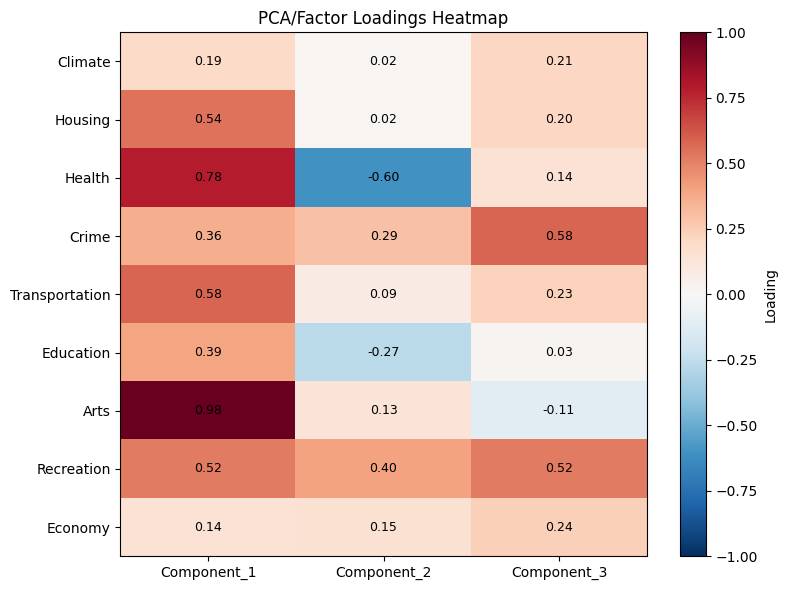

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(loadings.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(loadings.columns)))
ax.set_xticklabels(loadings.columns)
ax.set_yticks(range(len(loadings.index)))
ax.set_yticklabels(loadings.index)
for i in range(loadings.shape[0]):
    for j in range(loadings.shape[1]):
        ax.text(j, i, f"{loadings.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, label="Loading")
plt.title("PCA/Factor Loadings Heatmap")
plt.tight_layout()
plt.show()


### Result

| Component | Dominant variable | Loading |
|---|---|---|
| **Component 1** | Arts | 0.985 |
| **Component 2** | Health | -0.605 |
| **Component 3** | Crime | 0.585 |

- **Component 1** also has strong secondary loadings on Health (0.782), Transportation (0.585),
  Housing (0.544), and Recreation (0.520) — it behaves like a broad **"quality of life / general
  amenities"** component, anchored by Arts.
- **Component 2** is dominated by Health (negative loading), making it a **Health-contrast**
  component.
- **Component 3** is dominated by Crime, with Recreation close behind — a **Crime/Recreation**
  component.